# Train — ResNet-18

Trains and evaluates ResNet-18 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet18"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1752 | Val: 495 | Test: 280


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet18"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-18: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders, same as every other architecture
# here -- its own (capped) batch size and image size, per cfg.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-18: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model (Transfer Learning with ResNet-18)

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-18)
# ---------------------------------------------------------
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the tuned step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-18] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[ResNet-18] Epoch   1/100 | LR: 3.88e-04 | train loss 0.8542 acc 0.623 | val loss 0.9926 acc 0.651 *


[ResNet-18] Epoch   2/100 | LR: 3.88e-04 | train loss 0.5774 acc 0.723 | val loss 0.7448 acc 0.669 *


[ResNet-18] Epoch   3/100 | LR: 3.88e-04 | train loss 0.4646 acc 0.783 | val loss 0.5961 acc 0.788 *


[ResNet-18] Epoch   4/100 | LR: 3.88e-04 | train loss 0.3517 acc 0.843 | val loss 0.8635 acc 0.655


...

[ResNet-18] Epoch  11/100 | LR: 3.88e-04 | train loss 0.0706 acc 0.965 | val loss 0.6339 acc 0.834


[ResNet-18] Epoch  12/100 | LR: 3.88e-05 | train loss 0.0806 acc 0.963 | val loss 0.7777 acc 0.806


[ResNet-18] Epoch  13/100 | LR: 3.88e-05 | train loss 0.0477 acc 0.982 | val loss 0.6827 acc 0.820


[ResNet-18] Epoch  14/100 | LR: 3.88e-05 | train loss 0.0239 acc 0.989 | val loss 0.6709 acc 0.830


[ResNet-18] Epoch  15/100 | LR: 3.88e-05 | train loss 0.0215 acc 0.990 | val loss 0.6769 acc 0.836

[ResNet-18] No val loss improvement for 10 epochs — stopping early at epoch 15.

[ResNet-18] Restored best checkpoint (val loss = 0.5696)


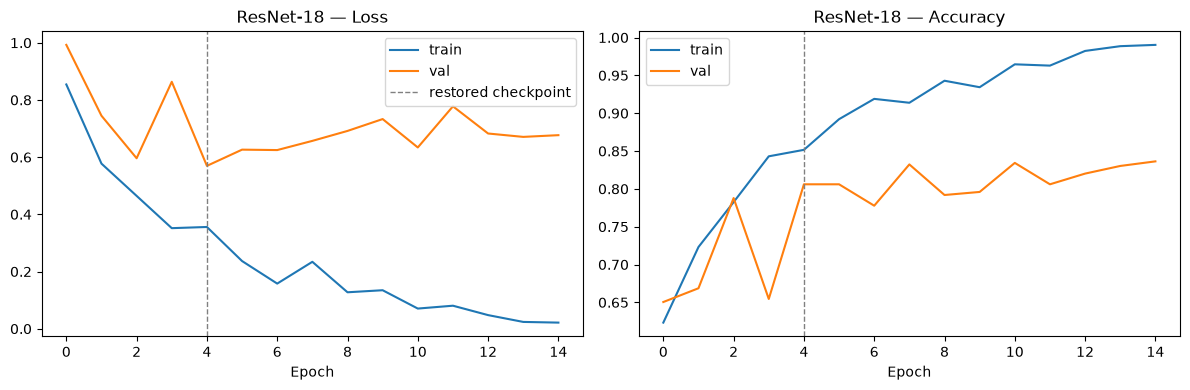

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.850


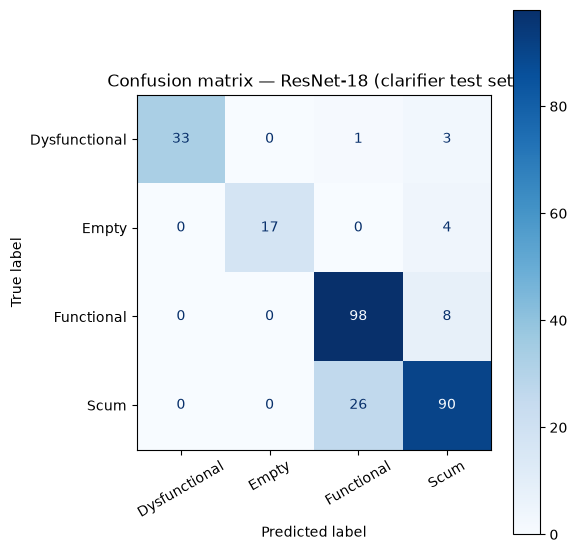

               precision    recall  f1-score   support

Dysfunctional      1.000     0.892     0.943        37
        Empty      1.000     0.810     0.895        21
   Functional      0.784     0.925     0.848       106
         Scum      0.857     0.776     0.814       116

     accuracy                          0.850       280
    macro avg      0.910     0.850     0.875       280
 weighted avg      0.859     0.850     0.850       280



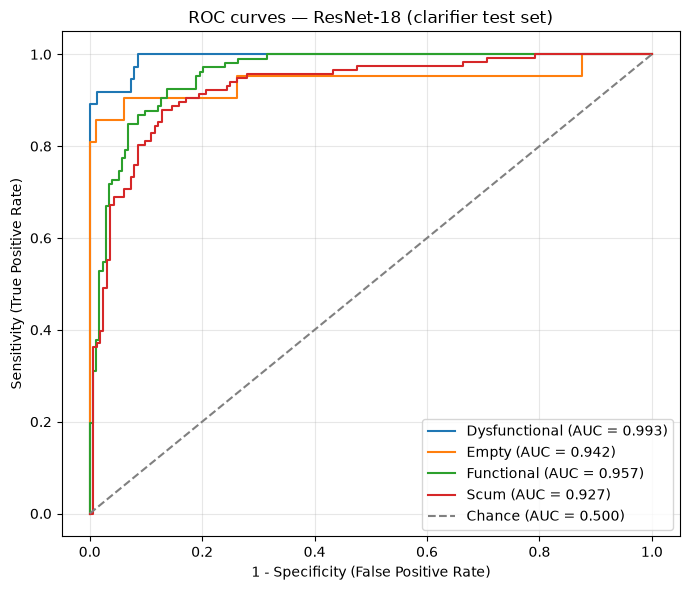

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.993
  Empty          : 0.942
  Functional     : 0.957
  Scum           : 0.927

Mean AUC (over 4/4 classes with test examples): 0.955


(np.float64(0.85),
 {'Dysfunctional': 0.9932154376598822,
  'Empty': 0.9422687994116565,
  'Functional': 0.9567881153762741,
  'Scum': 0.9271446593776281})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-18", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [6]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/clarifier_noaug/results_clarifier_resnet18_stratified.pkl


Saved model weights to ../models/clarifier_resnet18_cnn.pt
